# Ứng dụng GMM kết hợp HMM trong nhận diện hình vẽ tay

Notebook này trình bày cơ sở lý thuyết và cài đặt cho bài toán **nhận diện hình vẽ tay** dựa trên mô hình **GMM kết hợp HMM**, áp dụng cho bộ dữ liệu [Quick, Draw!](https://quickdraw.withgoogle.com/data) của Google.

---
# I) Cơ sở lý thuyết
---

## 1.1. Đặt vấn đề

Một hình vẽ tay (được vẽ bằng chuột/bút) không phải là một bức ảnh tĩnh, mà là **một chuỗi các điểm toạ độ theo thời gian** $O = (o_1, o_2, \dots, o_T)$, với $o_t = (x_t, y_t) \in \mathbb{R}^2$ là vị trí con trỏ tại thời điểm $t$. Đây chính xác là một **chuỗi thời gian nhiều chiều (multivariate time series)**.

Bài toán đặt ra: cho một chuỗi quan sát $O$, hãy xác định hình vẽ đó thuộc lớp nào trong tập các lớp đã biết (circle, square, triangle, zigzag, envelope, ...).

Hai mô hình được kết hợp để giải bài toán này:

- **GMM (Gaussian Mixture Model)**: mô hình hoá **phân phối của các điểm quan sát** (emission distribution) tại mỗi trạng thái ẩn.
- **HMM (Hidden Markov Model)**: mô hình hoá **sự phụ thuộc/chuyển tiếp theo thời gian** giữa các trạng thái ẩn (vd: trạng thái "đang vẽ cạnh trên" → "đang vẽ cạnh phải" của hình vuông).

Mỗi lớp hình vẽ sẽ có **1 mô hình HMM-GMM riêng**; khi cần phân loại, ta tính xác suất $P(O \mid \lambda_c)$ của chuỗi quan sát dưới từng mô hình lớp $\lambda_c$, và chọn lớp có xác suất cao nhất.

## 1.2. Gaussian Mixture Model (GMM)

GMM giả định dữ liệu được sinh ra từ tổ hợp tuyến tính của $K$ phân phối Gauss đa biến:

$$
p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

trong đó:

- $p(x)$: mật độ xác suất của điểm quan sát $x$ theo mô hình GMM.
- $K$: số thành phần Gauss trong hỗn hợp; $k = 1, \dots, K$ là chỉ số của từng thành phần.
- $\pi_k$: **trọng số trộn** (mixing weight) của thành phần $k$ — xác suất tiên nghiệm để một điểm được sinh ra từ thành phần đó, thoả $\pi_k \geq 0$ và $\sum_k \pi_k = 1$.
- $\mathcal{N}(x \mid \mu_k, \Sigma_k)$: mật độ Gauss đa biến của thành phần $k$ (công thức ngay bên dưới).
- $\mu_k$, $\Sigma_k$: vector kỳ vọng (tâm) và ma trận hiệp phương sai (hình dạng, độ trải) của thành phần $k$.

Trong đó mỗi thành phần Gauss có dạng:

$$
\mathcal{N}(x \mid \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{D/2} |\Sigma_k|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_k)^{T} \Sigma_k^{-1} (x-\mu_k)\right)
$$

trong đó:

- $x \in \mathbb{R}^D$: điểm quan sát; $D$ là số chiều của $x$ (ở đây $D=2$, ứng với $(x,y)$).
- $\mu_k \in \mathbb{R}^D$: vector kỳ vọng của thành phần $k$.
- $\Sigma_k \in \mathbb{R}^{D \times D}$: ma trận hiệp phương sai của thành phần $k$ (đối xứng, xác định dương).
- $|\Sigma_k|$: định thức của $\Sigma_k$; $\Sigma_k^{-1}$: ma trận nghịch đảo của $\Sigma_k$.
- $(\cdot)^{T}$: phép chuyển vị.
- $(x-\mu_k)^{T} \Sigma_k^{-1} (x-\mu_k)$: bình phương khoảng cách Mahalanobis từ $x$ đến tâm $\mu_k$ — đo độ lệch của $x$ có tính đến hình dạng phân phối.
- $\dfrac{1}{(2\pi)^{D/2} |\Sigma_k|^{1/2}}$: hệ số chuẩn hoá để tích phân của mật độ trên toàn không gian bằng 1.

### Thuật toán EM (Expectation-Maximization)

Vì không biết trước điểm nào thuộc thành phần Gauss nào (biến ẩn $z_n$), ta dùng EM để ước lượng $\{\pi_k, \mu_k, \Sigma_k\}$ bằng cách lặp 2 bước:

**E-step** — tính trách nhiệm (responsibility) $\gamma(z_{nk})$: xác suất điểm $x_n$ thuộc thành phần $k$:

$$
\gamma(z_{nk}) = \frac{\pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_n \mid \mu_j, \Sigma_j)}
$$

trong đó:

- $n = 1, \dots, N$: chỉ số điểm dữ liệu; $x_n$ là điểm dữ liệu thứ $n$.
- $z_n$: **biến ẩn** (latent variable) cho biết điểm $x_n$ do thành phần Gauss nào sinh ra ($z_{nk}=1$ nếu do thành phần $k$).
- $\gamma(z_{nk}) = P(z_{nk}=1 \mid x_n)$: xác suất hậu nghiệm (trách nhiệm) của thành phần $k$ đối với điểm $x_n$; với mỗi $n$ ta có $\sum_k \gamma(z_{nk}) = 1$.
- $\pi_k, \mu_k, \Sigma_k$: tham số của thành phần $k$ ở vòng lặp hiện tại.
- Tử số $\pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)$: mức độ thành phần $k$ "giải thích" được $x_n$; mẫu số là tổng của tử số qua mọi thành phần $j = 1, \dots, K$, đóng vai trò chuẩn hoá.

**M-step** — cập nhật lại tham số dựa trên $\gamma(z_{nk})$ vừa tính:

$$
N_k = \sum_{n=1}^{N} \gamma(z_{nk})
\qquad
\mu_k = \frac{1}{N_k}\sum_{n=1}^{N} \gamma(z_{nk}) \, x_n
$$

trong đó:

- $N$: tổng số điểm dữ liệu.
- $N_k$: "số điểm hiệu dụng" thuộc thành phần $k$ (tổng trách nhiệm của thành phần $k$ trên toàn bộ dữ liệu).
- $\mu_k$ (mới): trung bình của các điểm $x_n$, có trọng số là $\gamma(z_{nk})$ — điểm nào thuộc về thành phần $k$ nhiều hơn thì đóng góp nhiều hơn vào tâm mới.

$$
\Sigma_k = \frac{1}{N_k}\sum_{n=1}^{N} \gamma(z_{nk}) (x_n - \mu_k)(x_n - \mu_k)^{T}
\qquad
\pi_k = \frac{N_k}{N}
$$

trong đó:

- $\Sigma_k$ (mới): ma trận hiệp phương sai có trọng số $\gamma(z_{nk})$ của các điểm quanh tâm $\mu_k$ vừa cập nhật.
- $(x_n - \mu_k)(x_n - \mu_k)^{T}$: ma trận $D \times D$ (tích ngoài của vector độ lệch với chính nó).
- $\pi_k$ (mới): tỉ lệ số điểm hiệu dụng của thành phần $k$ trên tổng số điểm $N$, do đó $\sum_k \pi_k = 1$.

Lặp lại E-step/M-step đến khi log-likelihood hội tụ:

$$
\ln p(X \mid \pi, \mu, \Sigma) = \sum_{n=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k) \right)
$$

trong đó:

- $X = \{x_1, \dots, x_N\}$: toàn bộ tập dữ liệu; các điểm được giả định độc lập nên likelihood là tích, log-likelihood là tổng.
- $\ln p(X \mid \pi, \mu, \Sigma)$: log-likelihood của dữ liệu theo bộ tham số hiện tại; EM đảm bảo giá trị này **không giảm** sau mỗi vòng lặp.
- Biểu thức trong ngoặc $\sum_{k} \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)$ chính là $p(x_n)$ của công thức GMM ở đầu mục.

### Khởi tạo bằng K-means

EM rất nhạy với điểm khởi tạo (dễ hội tụ về cực trị địa phương xấu nếu khởi tạo ngẫu nhiên). Trong notebook này, tham số khởi tạo $(\pi^{(0)}, \mu^{(0)}, \Sigma^{(0)})$ được lấy từ kết quả phân cụm **K-means**: mean của mỗi cụm K-means làm $\mu_k^{(0)}$, tỉ lệ số điểm mỗi cụm làm $\pi_k^{(0)}$, và hiệp phương sai từng cụm làm $\Sigma_k^{(0)}$. Cách này giúp EM hội tụ nhanh hơn nhiều so với khởi tạo ngẫu nhiên.

## 1.3. Hidden Markov Model (HMM)

Một HMM được xác định bởi bộ tham số $\lambda = (A, B, \pi)$:

- Tập $N$ trạng thái ẩn $S = \{s_1, \dots, s_N\}$
- **Ma trận chuyển trạng thái** $A = [a_{ij}]$, với $a_{ij} = P(q_{t+1}=s_j \mid q_t = s_i)$
- **Phân phối phát xạ (emission)** $B = \{b_j(o_t)\}$, với $b_j(o_t) = P(o_t \mid q_t = s_j)$ — trong bài toán này, $b_j$ chính là 1 GMM
- **Phân phối trạng thái khởi tạo** $\pi = [\pi_i]$, với $\pi_i = P(q_1 = s_i)$

### Thuật toán Forward

Để tính $P(O \mid \lambda)$ — xác suất chuỗi quan sát $O$ sinh ra bởi mô hình $\lambda$ — ta dùng thuật toán forward với biến $\alpha_t(j) = P(o_1, \dots, o_t, q_t = s_j \mid \lambda)$:

$$
\alpha_1(j) = \pi_j \, b_j(o_1)
$$

trong đó:

- $\alpha_1(j)$: xác suất quan sát $o_1$ và đang ở trạng thái $s_j$ tại thời điểm đầu tiên.
- $\pi_j = P(q_1 = s_j)$: xác suất bắt đầu chuỗi ở trạng thái $s_j$ (đây là phân phối khởi tạo của HMM, **không** phải trọng số trộn $\pi_k$ của GMM).
- $b_j(o_1)$: xác suất phát xạ của quan sát đầu tiên $o_1$ tại trạng thái $s_j$.

$$
\alpha_{t+1}(j) = \left[ \sum_{i=1}^{N} \alpha_t(i) \, a_{ij} \right] b_j(o_{t+1})
$$

trong đó:

- $\alpha_t(i)$: xác suất quan sát $o_1, \dots, o_t$ và đang ở trạng thái $s_i$ tại thời điểm $t$.
- $a_{ij}$: xác suất chuyển từ trạng thái $s_i$ sang $s_j$.
- $\sum_{i=1}^{N} \alpha_t(i)\, a_{ij}$: tổng xác suất "đi đến" trạng thái $s_j$ ở bước $t+1$ từ mọi trạng thái $s_i$ có thể.
- $b_j(o_{t+1})$: xác suất trạng thái $s_j$ phát ra quan sát $o_{t+1}$.
- $N$: số trạng thái ẩn; $j = 1, \dots, N$.

$$
P(O \mid \lambda) = \sum_{i=1}^{N} \alpha_T(i)
$$

trong đó:

- $P(O \mid \lambda)$: xác suất (likelihood) chuỗi quan sát $O$ được sinh ra bởi mô hình $\lambda = (A, B, \pi)$.
- $T$: độ dài chuỗi quan sát (thời điểm cuối cùng).
- $\alpha_T(i)$: xác suất quan sát toàn bộ chuỗi và kết thúc ở trạng thái $s_i$; cộng qua mọi trạng thái cuối $i = 1, \dots, N$ để loại bỏ biến ẩn.

### Cấu trúc "forward-only" (Bakis model) áp dụng cho bài toán này

Vì mỗi hình vẽ được vẽ theo 1 trình tự thời gian cố định (vd: hình vuông luôn được vẽ tuần tự cạnh trên → phải → dưới → trái), ta dùng cấu trúc HMM **forward-only (Bakis model)**:

$$
\pi = [1, 0, 0, \dots, 0] \quad \text{(luôn bắt đầu ở trạng thái 0)}
$$

trong đó $\pi$ là vector độ dài $N$ với phần tử thứ $i$ là $P(q_1 = s_i)$: phần tử đầu bằng 1 (trạng thái đầu tiên, chỉ số 0 trong code) và các phần tử còn lại bằng 0.

$$
a_{ij} = \begin{cases} p_{\text{self}} & j = i \\ 1-p_{\text{self}} & j = i+1 \\ 0 & \text{khác} \end{cases}
$$

trong đó:

- $a_{ij}$: xác suất chuyển từ trạng thái $i$ sang trạng thái $j$.
- $p_{\text{self}}$: xác suất **ở lại** trạng thái hiện tại (siêu tham số `SELF_LOOP_PROB`).
- $1 - p_{\text{self}}$: xác suất **chuyển sang trạng thái kế tiếp** $i+1$.
- $j = i$ và $j = i+1$ là 2 chuyển tiếp duy nhất được phép; mọi chuyển tiếp còn lại (gồm quay ngược lại) có xác suất 0.

Nghĩa là tại mỗi trạng thái, chuỗi chỉ có thể **ở lại trạng thái hiện tại** hoặc **chuyển sang đúng trạng thái kế tiếp**, không có đường quay lại — phù hợp với việc 1 nét vẽ luôn tiến về phía trước theo thời gian.

## 1.4. Kết hợp GMM-HMM

Với mỗi trạng thái ẩn $s_j$ của HMM, thay vì dùng 1 phân phối Gauss đơn, ta dùng 1 **GMM** làm phân phối phát xạ:

$$
b_j(o_t) = \sum_{k=1}^{K_j} \pi_{jk} \, \mathcal{N}(o_t \mid \mu_{jk}, \Sigma_{jk})
$$

trong đó:

- $b_j(o_t)$: xác suất phát xạ của quan sát $o_t$ tại trạng thái ẩn $s_j$.
- $o_t = (x_t, y_t)$: điểm toạ độ quan sát tại thời điểm $t$.
- $K_j$: số thành phần Gauss trong GMM của trạng thái $s_j$ (siêu tham số `N_MIX`).
- $\pi_{jk}$: trọng số trộn của thành phần $k$ trong GMM của trạng thái $s_j$, với $\sum_{k} \pi_{jk} = 1$.
- $\mu_{jk}$, $\Sigma_{jk}$: vector kỳ vọng và ma trận hiệp phương sai của thành phần $k$ trong trạng thái $s_j$.

Kiến trúc tổng thể: **GMM** đảm nhiệm việc mô tả "điểm quan sát tại 1 thời điểm/trạng thái trông như thế nào" (vd: cụm điểm nằm ở góc trên-trái của hình vuông), còn **HMM** đảm nhiệm việc mô tả "chuỗi các trạng thái đó nối tiếp nhau theo thời gian ra sao" (vd: từ góc trên-trái phải chuyển sang góc trên-phải). Đây chính là ý nghĩa của "mô hình hoá chuỗi thời gian nhiều chiều dựa trên GMM kết hợp với một mô hình chuỗi thời gian như HMM".

**Cách huấn luyện** trong notebook này (segmental K-means, một biến thể đơn giản hoá của Baum-Welch): với mỗi lớp, chuẩn hoá từng mẫu vẽ rồi chia đều chuỗi điểm thành $N$ phần theo đúng thứ tự vẽ (mỗi phần ứng với 1 trạng thái), dồn các điểm cùng vị trí trạng thái của mọi mẫu trong lớp lại, rồi huấn luyện 1 GMM (K-means init + EM) riêng cho trạng thái đó.

**Cách phân loại**: với 1 chuỗi quan sát mới, tính $P(O \mid \lambda_c)$ (thuật toán forward, ở dạng log để tránh tràn số) cho từng lớp $c$, chọn lớp có log-likelihood cao nhất:

$$
\hat{c} = \arg\max_{c} \; \log P(O \mid \lambda_c)
$$

trong đó:

- $\hat{c}$: lớp được dự đoán cho chuỗi quan sát $O$.
- $c$: chỉ số lớp hình vẽ, chạy qua toàn bộ các lớp trong `CATEGORIES`.
- $\lambda_c$: mô hình HMM-GMM đã huấn luyện cho lớp $c$.
- $\log P(O \mid \lambda_c)$: log-likelihood của chuỗi $O$ dưới mô hình lớp $c$, tính bằng thuật toán forward.
- $\arg\max_c$: chọn lớp $c$ cho log-likelihood lớn nhất.


---
# II) Cài đặt thuật toán và kết quả
---

## 2.1. Import thư viện và cấu hình

Toàn bộ GMM/EM/K-means được cài đặt thủ công bằng NumPy (không dùng `sklearn.mixture` hay `hmmlearn`). Chỉ dùng `scipy.special.logsumexp` để tính tổng log-xác suất ổn định số học (log-domain), và `matplotlib` để vẽ kết quả.

`CATEGORIES` là danh sách các lớp hình vẽ sẽ huấn luyện, đọc từ các file `.ndjson` (định dạng raw của QuickDraw) đặt trong thư mục `data/` cùng cấp với notebook.

In [1]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
# 1. CẤU HÌNH
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
BASE_DIR = os.getcwd()  # trong notebook, thư mục hiện tại chính là nơi đặt file
DATA_DIR = os.path.join(BASE_DIR, "data")               
OUTPUT_DIR = os.path.join(DATA_DIR, "training_output")  
CATEGORIES = ["circle", "square", "triangle", "zigzag" , "envelope"]
SAMPLES_PER_CLASS = 400      # số mẫu vẽ tối đa đọc từ mỗi file .ndjson

# Tỉ lệ chia dữ liệu của từng lớp (tổng phải bằng 1)
TRAIN_RATIO = 0.6            # tập train: học tham số GMM cho từng trạng thái
VAL_RATIO = 0.2              # tập validation: chọn siêu tham số tối ưu
TEST_RATIO = 0.2             # tập test: chỉ dùng để đánh giá cuối cùng
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

# Lưới siêu tham số được thử trên tập validation (mục 2.18).
# Bộ (N_STATES, N_MIX, SELF_LOOP_PROB) tốt nhất sẽ được gán tự động sau bước đó.
N_STATES_GRID = [3, 4, 5, 6]        # số trạng thái ẩn
N_MIX_GRID = [1, 2, 3]              # số Gaussian component trong GMM của mỗi trạng thái
SELF_LOOP_GRID = [0.5, 0.65, 0.8, 0.9]   # xác suất ở lại trạng thái hiện tại
RETRAIN_ON_TRAIN_VAL = True  # True: sau khi chọn xong siêu tham số, huấn luyện lại model cuối trên train + val

EM_MAX_ITER = 100
EM_TOL = 1e-5
RANDOM_STATE = 42

MIN_POINTS_PER_SEQUENCE = 12   # bỏ mẫu vẽ quá ít điểm (đặt cố định để mọi tổ hợp siêu tham số dùng chung 1 tập dữ liệu)

MODEL_PATH = os.path.join(OUTPUT_DIR, "gmm_hmm_models.pkl")

## 2.2. Mật độ Gaussian đa biến 

Cài đặt công thức $\mathcal{N}(x \mid \mu, \Sigma)$ ở mục 1.2, tính theo **log-domain** rồi mới `exp()` ra để tránh tràn số (underflow) khi định thức $|\Sigma|$ rất nhỏ hoặc rất lớn. Nếu ma trận hiệp phương sai không xác định dương (do dữ liệu suy biến), cộng thêm 1 lượng nhỏ vào đường chéo để đảm bảo khả nghịch.

In [2]:
def gaussian_pdf(x, mean, cov):
    """Tính giá trị mật độ Gaussian đa biến cho một hoặc nhiều điểm."""
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)

    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)

    diff = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-6 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)

    inv_cov = np.linalg.inv(cov)
    quad = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    d = mean.shape[0]
    log_pdf = -0.5 * (d * np.log(2 * np.pi) + logdet + quad)
    vals = np.exp(log_pdf)
    return float(vals[0]) if original_shape == (d,) else vals

## 2.3. E-step

Cài đặt công thức $\gamma(z_{nk})$ ở mục 1.2: tính xác suất hậu nghiệm mỗi điểm thuộc về từng thành phần Gauss, dùng `logsumexp` để chuẩn hoá theo hàng một cách ổn định số học (tránh chia cho số quá nhỏ).

In [3]:
def e_step(X, pi, means, covs):
    """E-step: tính responsibility R[n, k] = p(z_n=k | x_n, theta)."""
    N, D = X.shape
    K = len(pi)
    log_prob = np.empty((N, K))
    for k in range(K):
        pdf = gaussian_pdf(X, means[k], covs[k])
        pdf = np.clip(pdf, 1e-300, None)
        log_prob[:, k] = np.log(np.clip(pi[k], 1e-300, None)) + np.log(pdf)
    log_total = logsumexp(log_prob, axis=1, keepdims=True)
    R = np.exp(log_prob - log_total)
    return R

## 2.4. M-step 

Cài đặt công thức cập nhật $N_k, \mu_k, \Sigma_k, \pi_k$ ở mục 1.2 từ ma trận trách nhiệm `R` vừa tính ở E-step. Nếu 1 thành phần "chết" (không có điểm nào thuộc về nó, $N_k \approx 0$), fallback về mean/cov của toàn bộ dữ liệu để tránh chia cho 0.

In [4]:
def m_step(X, R):
    """M-step: cập nhật pi, means, covs từ R[n, k]."""
    N, D = X.shape
    K = R.shape[1]
    Nk = R.sum(axis=0)

    pi = Nk / N
    means = np.empty((K, D))
    covs = np.empty((K, D, D))
    for k in range(K):
        if Nk[k] < 1e-12:
            means[k] = X.mean(axis=0)
            covs[k] = np.cov(X.T) + 1e-6 * np.eye(D)
            continue
        means[k] = (R[:, k][:, None] * X).sum(axis=0) / Nk[k]
        diff = X - means[k]
        cov = (R[:, k][:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) / Nk[k]
        cov = 0.5 * (cov + cov.T)
        cov += 1e-6 * np.eye(D)
        covs[k] = cov

    return pi, means, covs

## 2.5. Log-likelihood tổng thể

Tính $\ln p(X \mid \pi, \mu, \Sigma)$ theo công thức ở mục 1.2 — giá trị này được theo dõi qua từng vòng lặp EM để kiểm tra sự hội tụ (dùng cho `ll_history` ở phần vẽ kết quả).

In [5]:
def log_likelihood(X, pi, means, covs):
    """Tính log-likelihood của toàn bộ dữ liệu."""
    total = np.zeros(X.shape[0])
    for k in range(len(pi)):
        total += pi[k] * gaussian_pdf(X, means[k], covs[k])
    total = np.clip(total, 1e-300, None)
    return np.sum(np.log(total))

## 2.6. K-means thủ công
Cài đặt K-means kinh điển (gán nhãn theo khoảng cách Euclid gần nhất → cập nhật lại centroid) để dùng làm bước khởi tạo cho EM (mục 1.2). Dừng sớm nếu nhãn không đổi giữa 2 vòng lặp liên tiếp.

In [6]:
def kmeans(X, K, max_iter=100, random_state=0):
    """K-means cài đặt thủ công """
    rng = np.random.default_rng(random_state)
    centers = X[rng.choice(X.shape[0], size=K, replace=False)].copy()
    labels = np.zeros(X.shape[0], dtype=int)
    for _ in range(max_iter):
        distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = distances.argmin(axis=1)
        if np.all(new_labels == labels):
            break
        labels = new_labels
        new_centers = np.empty_like(centers)
        for k in range(K):
            if np.any(labels == k):
                new_centers[k] = X[labels == k].mean(axis=0)
            else:
                new_centers[k] = centers[k]
        centers = new_centers

    return labels, centers

## 2.7. Khởi tạo GMM từ K-means 

Dùng kết quả phân cụm K-means ở trên để khởi tạo $(\pi^{(0)}, \mu^{(0)}, \Sigma^{(0)})$ cho GMM, như đã giải thích ở mục 1.2 — giúp EM hội tụ nhanh hơn nhiều so với khởi tạo ngẫu nhiên.

In [7]:
def initialize_gmm_from_kmeans(X, K, random_state=0):
    """Khởi tạo tham số GMM (pi, means, covs) bằng kết quả phân cụm K-means."""
    labels_init, centers_init = kmeans(X, K=K, random_state=random_state)
    N, D = X.shape

    pi0 = np.array([np.mean(labels_init == k) for k in range(K)])
    means0 = centers_init.copy()

    covs0 = np.zeros((K, D, D))
    for k in range(K):
        pts = X[labels_init == k]
        if len(pts) > 1:
            covs0[k] = np.cov(pts.T) + 1e-6 * np.eye(D)
        else:
            covs0[k] = np.cov(X.T) + 1e-6 * np.eye(D)

    return pi0, means0, covs0

## 2.8. Vòng lặp EM đầy đủ 

Ghép E-step + M-step thành 1 vòng lặp hoàn chỉnh, dừng khi log-likelihood hội tụ (thay đổi giữa 2 vòng liên tiếp nhỏ hơn `EM_TOL`) hoặc đạt `EM_MAX_ITER`. Trả về cả `ll_history` để vẽ đường cong hội tụ ở phần sau.

In [8]:
def gmm_em_from_init(X, pi0, means0, covs0, max_iter=EM_MAX_ITER, tol=EM_TOL):
    """Chạy thuật toán EM cho GMM, xuất phát từ tham số khởi tạo bằng K-means."""
    pi, means, covs = pi0.copy(), means0.copy(), covs0.copy()
    ll_history = []
    prev_ll = -np.inf

    for it in range(1, max_iter + 1):
        R = e_step(X, pi, means, covs)
        pi, means, covs = m_step(X, R)
        ll = log_likelihood(X, pi, means, covs)
        ll_history.append(ll)
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return pi, means, covs, R, ll_history

## 2.9. Đọc dữ liệu QuickDraw 

Đọc file `.ndjson` (định dạng raw, có toạ độ gốc) của 1 category, chỉ giữ lại các bản vẽ có `recognized: true` (được game AI xác nhận vẽ đúng), gộp toạ độ tất cả các nét (stroke) thành 1 chuỗi điểm `(T, 2)` theo đúng thứ tự vẽ. Bỏ qua các mẫu quá ít điểm (`MIN_POINTS_PER_SEQUENCE`).

In [9]:
def load_category_sequences(category, data_dir, limit):
    """Đọc file .ndjson raw của 1 category, trả về list các chuỗi điểm (T,2)."""
    filename = category.replace(" ", "_") + ".ndjson"
    path = os.path.join(data_dir, filename)
    sequences = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if len(sequences) >= limit:
                break
            obj = json.loads(line)
            if not obj.get("recognized", True):
                continue  # bỏ các bản vẽ bị người chơi vẽ sai/không rõ
            points = []
            for stroke in obj["drawing"]:
                xs, ys = stroke[0], stroke[1]
                points.extend(zip(xs, ys))

            if len(points) < MIN_POINTS_PER_SEQUENCE:
                continue
            sequences.append(np.array(points, dtype=float))
    return sequences

## 2.10. Chuẩn hoá và chia trạng thái 

- `normalize_sequence`: chuẩn hóa Z-score— giúp model bất biến với vị trí và tỉ lệ vẽ khác nhau giữa các lần vẽ.
- `segment_sequence`: chia đều chuỗi điểm đã chuẩn hoá thành `n_states` phần liên tiếp theo đúng thứ tự vẽ — đây là cách khởi tạo gán nhãn trạng thái cho mô hình forward-only đã nêu ở mục 1.3/1.4 (vd: hình vuông chia thành 4 phần ứng với 4 cạnh).

In [10]:
def normalize_sequence(points):
    """Chuẩn hoá 1 chuỗi điểm: trừ mean, chia std ."""
    mean = points.mean(axis=0)
    std = points.std(axis=0)
    std = np.where(std < 1e-6, 1e-6, std)
    return (points - mean) / std
def segment_sequence(points, n_states):
    """Chia chuỗi điểm (đã chuẩn hoá) thành n_states phần liên tiếp theo đúng
    thứ tự vẽ - đây chính là cách khởi tạo trạng thái mà bài báo đề xuất cho
    forward-only HMM (vd: circle chia thành 4 phần = 4 quadrant)."""
    T = len(points)
    boundaries = np.linspace(0, T, n_states + 1).astype(int)
    segments = []
    for i in range(n_states):
        seg = points[boundaries[i]:boundaries[i + 1]]
        if len(seg) == 0:
            idx = min(boundaries[i], T - 1)
            seg = points[idx:idx + 1]
        segments.append(seg)
    return segments

## 2.11. Tách tập train/validation/test 

Xáo trộn ngẫu nhiên (có `random_state` cố định để tái lập kết quả) rồi tách **riêng cho từng lớp** theo tỉ lệ `TRAIN_RATIO : VAL_RATIO : TEST_RATIO` = 0,6 : 0,2 : 0,2 (nên tỉ lệ các lớp được giữ đồng đều ở cả 3 tập). Vai trò của từng tập:

- **Train**: học tham số GMM của từng trạng thái.
- **Validation**: so sánh các tổ hợp siêu tham số để chọn ra tổ hợp tốt nhất (mục 2.18).
- **Test**: chỉ dùng 1 lần ở cuối để báo cáo chất lượng mô hình cuối cùng — vì không tham gia vào việc chọn siêu tham số nên kết quả không bị lạc quan giả tạo.

In [11]:
def train_val_test_split(sequences, train_ratio, val_ratio, test_ratio, random_state):
    """Chia 1 danh sách chuỗi thành (train, val, test) theo tỉ lệ cho trước."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(sequences))
    n_test = max(1, int(len(sequences) * test_ratio))
    n_val = max(1, int(len(sequences) * val_ratio))
    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]
    pick = lambda ids: [sequences[i] for i in ids]
    return pick(train_idx), pick(val_idx), pick(test_idx)

## 2.12. Emission log-probability của 1 trạng thái 

Tính $\log b_j(o_t)$ theo công thức GMM emission ở mục 1.4, tại 1 trạng thái cụ thể. Hàm nhận 1 điểm $(D,)$ hoặc cả 1 chuỗi điểm $(T, D)$ cùng lúc — dạng vector hoá này giúp thuật toán forward ở mục 2.13 chạy nhanh hơn nhiều, cần thiết khi phải đánh giá hàng chục tổ hợp siêu tham số ở mục 2.18.

In [12]:
def gmm_state_log_prob(x, gmm):
    """log p(x | trạng thái) với emission là GMM nhiều component.
    x: 1 điểm (D,) hoặc nhiều điểm (T, D) -> trả về số thực hoặc mảng (T,)."""
    x = np.asarray(x, dtype=float)
    total = 0.0
    for k in range(len(gmm["pi"])):
        total = total + gmm["pi"][k] * gaussian_pdf(x, gmm["means"][k], gmm["covs"][k])
    total = np.maximum(total, 1e-300)
    return np.log(total)

## 2.13. Thuật toán Forward (log-domain) 

Cài đặt chính xác công thức forward ở mục 1.3, với cấu trúc forward-only: tại mỗi bước thời gian, $\alpha_t(j)$ chỉ có thể nhận đóng góp từ $\alpha_{t-1}(j)$ (ở lại) hoặc $\alpha_{t-1}(j-1)$ (từ trạng thái liền trước) — dùng `np.logaddexp` (tương đương `logsumexp` cho 2 số hạng) để cộng 2 xác suất này trong log-domain một cách ổn định số học. Log-emission $\log b_j(o_t)$ của mọi thời điểm $t$ và mọi trạng thái $j$ được tính trước thành ma trận `(T, n_states)`, rồi vòng lặp theo thời gian chỉ còn thao tác trên vector.

In [13]:
def forward_log_likelihood(points, model):
    """Thuật toán forward (log-domain) tính P(O|lambda) cho HMM forward-only.

    - P (initial): luôn bắt đầu ở trạng thái 0 -> log_alpha[0] khởi tạo trực tiếp.
    - A (transition): chỉ có 2 khả năng từ trạng thái j: ở lại j (self_prob)
      hoặc sang j+1 (next_prob); không có đường quay lại.
    """
    n_states = model["n_states"]
    log_self = np.log(model["self_prob"])
    log_next = np.log(model["next_prob"])
    gmms = model["gmms"]

    # log b_j(o_t) cho mọi t, j -> ma trận (T, n_states)
    log_b = np.column_stack([gmm_state_log_prob(points, g) for g in gmms])

    log_alpha = np.full(n_states, -np.inf)
    log_alpha[0] = log_b[0, 0]  # log(P[0]=1) = 0
    for t in range(1, len(points)):
        stay = log_alpha + log_self                    # từ chính trạng thái j
        move = np.full(n_states, -np.inf)
        move[1:] = log_alpha[:-1] + log_next           # từ trạng thái j-1
        log_alpha = np.logaddexp(stay, move) + log_b[t]
    return logsumexp(log_alpha)

## 2.14. Huấn luyện 1 mô hình HMM-GMM cho 1 lớp 

Ghép toàn bộ các bước ở mục 1.4 lại: với mỗi mẫu vẽ trong tập train của 1 lớp, chuẩn hoá rồi chia thành `n_states` phần; dồn các điểm cùng vị trí trạng thái của mọi mẫu lại; huấn luyện 1 GMM riêng (K-means init + EM, mục 2.6-2.8) cho từng trạng thái.

In [14]:
def train_class_model(category, train_sequences, n_states, n_mix,
                       self_prob, random_state):
    """Huấn luyện 1 HMM-GMM forward-only cho 1 lớp cử chỉ.

    Bước khởi tạo: chuẩn hoá từng mẫu vẽ, chia đều thành n_states
    phần theo thứ tự vẽ, dồn toàn bộ điểm cùng vị trí trạng thái của mọi mẫu
    trong lớp lại -> huấn luyện 1 GMM (kmeans-init + EM) riêng cho trạng thái đó.
    """
    state_points = [[] for _ in range(n_states)]
    for seq in train_sequences:
        norm = normalize_sequence(seq)
        segments = segment_sequence(norm, n_states)
        for s, seg in enumerate(segments):
            state_points[s].extend(seg.tolist())
    gmms, ll_histories = [], []
    for s in range(n_states):
        X_s = np.array(state_points[s])
        if len(X_s) < 2:
            X_s = np.vstack([X_s, X_s + 1e-3]) if len(X_s) == 1 else \
                  np.random.default_rng(random_state).normal(size=(4, 2))
        k = max(1, min(n_mix, len(X_s) // 3))
        pi0, means0, covs0 = initialize_gmm_from_kmeans(X_s, K=k, random_state=random_state)
        pi_f, means_f, covs_f, _, ll_hist = gmm_em_from_init(X_s, pi0, means0, covs0)

        gmms.append({"pi": pi_f, "means": means_f, "covs": covs_f})
        ll_histories.append(ll_hist)
    return {
        "category": category,
        "n_states": n_states,
        "self_prob": self_prob,
        "next_prob": 1.0 - self_prob,
        "gmms": gmms,
        "ll_histories": ll_histories,
        "state_points": state_points,  # giữ lại để vẽ minh hoạ
    }

def predict(points, models):
    """Phân loại 1 chuỗi điểm: chọn model có log-likelihood cao nhất."""
    norm = normalize_sequence(points)
    scores = {cat: forward_log_likelihood(norm, m) for cat, m in models.items()}
    best_cat = max(scores, key=scores.get)
    return best_cat, scores

## 2.15. Xuất và nạp model 

Sau khi train xong, lưu toàn bộ tham số cần cho việc suy luận ra file `.pkl`, để dùng lại cho việc nhận diện sau này mà không cần train lại từ đầu.

In [15]:
def save_models(models, path):
    """Lưu toàn bộ model (1 HMM-GMM / lớp) ra file .pkl để dùng lại cho việc
    inference sau này (vd nạp vào app "Draw something!") mà không cần train lại.

    Chỉ lưu phần tham số cần cho việc suy luận (n_states, self_prob, next_prob,
    gmms) - bỏ "state_points" và "ll_histories" (chỉ dùng để vẽ plot, không cần
    cho lúc predict) để file gọn hơn.
    """
    export = {}
    for cat, model in models.items():
        export[cat] = {
            "category": model["category"],
            "n_states": model["n_states"],
            "self_prob": model["self_prob"],
            "next_prob": model["next_prob"],
            "gmms": model["gmms"],
        }

    with open(path, "wb") as f:
        pickle.dump({"categories": list(models.keys()), "models": export}, f)

    size_kb = os.path.getsize(path) / 1024
    print(f"[LƯU MODEL] {path} ({size_kb:.1f} KB)")
def load_models(path):
    """Nạp lại model đã lưu bằng save_models(). Trả về dict {category: model}
    dùng trực tiếp được với hàm predict()."""
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data["models"]

## 2.16. Các hàm vẽ kết quả


In [16]:
def plot_em_convergence(models, output_dir):
    """Vẽ đường cong hội tụ log-likelihood của EM cho từng trạng thái, mỗi lớp
    1 subplot - minh hoạ hiệu quả của việc khởi tạo bằng K-means."""
    n_cat = len(models)
    fig, axes = plt.subplots(1, n_cat, figsize=(4.2 * n_cat, 4), squeeze=False)
    axes = axes[0]

    for ax, (cat, model) in zip(axes, models.items()):
        for s, ll_hist in enumerate(model["ll_histories"]):
            ax.plot(range(1, len(ll_hist) + 1), ll_hist, marker='o',
                    markersize=3, linewidth=1.5, label=f"state {s}")
        ax.set_title(f"'{cat}' - EM convergence")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(output_dir, "01_em_convergence.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")


def plot_state_gaussians(model, output_dir):
    """Vẽ các điểm đã gán theo trạng thái + contour Gaussian đã học được,
    cho 1 lớp cử chỉ minh hoạ (giống style contour trong notebook gốc)."""
    n_states = model["n_states"]
    colors = plt.cm.tab10(np.linspace(0, 1, n_states))

    all_points = np.vstack(model["state_points"])
    min_x, max_x = all_points[:, 0].min() - 1, all_points[:, 0].max() + 1
    min_y, max_y = all_points[:, 1].min() - 1, all_points[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(min_x, max_x, 120), np.linspace(min_y, max_y, 120))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    fig, ax = plt.subplots(figsize=(7, 6))
    for s in range(n_states):
        pts = np.array(model["state_points"][s])
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, color=colors[s],
                   label=f"state {s}")
        gmm = model["gmms"][s]
        for k in range(len(gmm["pi"])):
            Z = gaussian_pdf(grid, gmm["means"][k], gmm["covs"][k]).reshape(xx.shape)
            ax.contour(xx, yy, Z, levels=5, colors=[colors[s]], alpha=0.8)

    ax.set_title(f"GMM đã học theo từng trạng thái - lớp '{model['category']}'")
    ax.set_xlabel("x (đã chuẩn hoá)")
    ax.set_ylabel("y (đã chuẩn hoá)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    path = os.path.join(output_dir, f"02_state_gaussians_{model['category']}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")


def plot_confusion_matrix(y_true, y_pred, categories, output_dir):
    n = len(categories)
    idx = {c: i for i, c in enumerate(categories)}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1

    fig, ax = plt.subplots(figsize=(1.4 * n + 2, 1.4 * n + 2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(categories)
    ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
    ax.set_title("Confusion matrix - tập test")

    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    path = os.path.join(output_dir, "03_confusion_matrix.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")
    return cm


def plot_accuracy_bar(y_true, y_pred, categories, output_dir):
    accs = []
    for cat in categories:
        idxs = [i for i, t in enumerate(y_true) if t == cat]
        correct = sum(1 for i in idxs if y_pred[i] == cat)
        accs.append(correct / len(idxs) if idxs else 0.0)

    overall = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)

    fig, ax = plt.subplots(figsize=(1.4 * len(categories) + 2, 4.5))
    bars = ax.bar(categories, accs, color="tab:blue", alpha=0.8)
    ax.axhline(overall, color="red", linestyle="--", label=f"Trung bình = {overall:.2%}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy theo từng lớp trên tập test")
    ax.legend()
    for b, a in zip(bars, accs):
        ax.text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.0%}", ha="center")

    plt.tight_layout()
    path = os.path.join(output_dir, "04_accuracy_per_class.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")
    return overall

## 2.17. Đọc dữ liệu

Đọc dữ liệu cho từng category trong `CATEGORIES` (tối đa `SAMPLES_PER_CLASS` = 400 mẫu/lớp), tách train/validation/test theo tỉ lệ 0,6 : 0,2 : 0,2.

In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_data, val_data, test_data = {}, {}, {}
for cat in CATEGORIES:
    seqs = load_category_sequences(cat, DATA_DIR, SAMPLES_PER_CLASS)
    tr, va, te = train_val_test_split(seqs, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_STATE)
    train_data[cat], val_data[cat], test_data[cat] = tr, va, te
    print(f"  {cat:12s}: {len(tr)} mẫu train, {len(va)} mẫu val, {len(te)} mẫu test")

  circle      : 240 mẫu train, 80 mẫu val, 80 mẫu test
  square      : 240 mẫu train, 80 mẫu val, 80 mẫu test
  triangle    : 240 mẫu train, 80 mẫu val, 80 mẫu test
  zigzag      : 240 mẫu train, 80 mẫu val, 80 mẫu test
  envelope    : 240 mẫu train, 80 mẫu val, 80 mẫu test


**Nhận xét:** số mẫu train/val/test hiển thị ở trên phản ánh số bản vẽ hợp lệ (`recognized: true` và đủ số điểm tối thiểu) đọc được từ mỗi file `.ndjson`, giới hạn bởi `SAMPLES_PER_CLASS`. Nếu 1 lớp có số mẫu ít hơn hẳn các lớp còn lại, đó có thể là dấu hiệu file `.ndjson` của lớp đó thiếu, hoặc ngưỡng `MIN_POINTS_PER_SEQUENCE` đang lọc bỏ quá nhiều mẫu vẽ ngắn của lớp đó — cần kiểm tra lại nếu accuracy của lớp này thấp bất thường ở bước đánh giá phía dưới.

## 2.18. Chọn siêu tham số tối ưu trên tập validation

Mô hình có 3 siêu tham số cần chọn: số trạng thái ẩn `N_STATES`, số Gaussian mỗi trạng thái `N_MIX`, và xác suất ở lại trạng thái `SELF_LOOP_PROB`. Quy trình (**grid search**):

1. Với mỗi tổ hợp trong lưới `N_STATES_GRID × N_MIX_GRID × SELF_LOOP_GRID`, huấn luyện trên tập **train**, đo accuracy trên tập **validation**.
2. Chọn tổ hợp có validation accuracy cao nhất; nếu hoà thì ưu tiên mô hình đơn giản hơn (`N_STATES × N_MIX` nhỏ hơn) để giảm nguy cơ overfit.
3. Tập **test** không tham gia vào việc chọn, chỉ dùng để đánh giá ở mục 2.20.

**Lưu ý tiết kiệm thời gian:** `SELF_LOOP_PROB` chỉ xuất hiện trong thuật toán forward (lúc chấm điểm), không ảnh hưởng bước huấn luyện GMM. Do đó với mỗi cặp `(N_STATES, N_MIX)` ta chỉ huấn luyện 1 lần rồi thử lần lượt các giá trị `SELF_LOOP_PROB`.

In [18]:
import time

def evaluate_accuracy(models, data):
    """Accuracy tổng thể của bộ model trên 1 tập dữ liệu dạng {category: [chuỗi điểm]}."""
    correct, total = 0, 0
    for cat, seqs in data.items():
        for seq in seqs:
            pred_cat, _ = predict(seq, models)
            correct += (pred_cat == cat)
            total += 1
    return correct / total

def with_self_prob(models, self_prob):
    """Bản sao bộ model với self_prob/next_prob khác (GMM giữ nguyên)."""
    return {cat: {**m, "self_prob": self_prob, "next_prob": 1.0 - self_prob}
            for cat, m in models.items()}

tuning_results = []
t0 = time.time()
for n_states in N_STATES_GRID:
    for n_mix in N_MIX_GRID:
        base_models = {cat: train_class_model(cat, train_data[cat], n_states, n_mix,
                                              SELF_LOOP_GRID[0], RANDOM_STATE)
                       for cat in CATEGORIES}
        for self_prob in SELF_LOOP_GRID:
            val_acc = evaluate_accuracy(with_self_prob(base_models, self_prob), val_data)
            tuning_results.append({"n_states": n_states, "n_mix": n_mix,
                                   "self_prob": self_prob, "val_acc": val_acc})
            print(f"N_STATES={n_states} | N_MIX={n_mix} | SELF_LOOP={self_prob:.2f} "
                  f"-> val accuracy = {val_acc:.2%}")
print(f"Tổng thời gian grid search: {time.time() - t0:.0f}s")

# Chọn tổ hợp tốt nhất: val accuracy cao nhất, hoà thì chọn mô hình đơn giản hơn
rank_key = lambda r: (r["val_acc"], -r["n_states"] * r["n_mix"])
best = max(tuning_results, key=rank_key)
N_STATES, N_MIX, SELF_LOOP_PROB = best["n_states"], best["n_mix"], best["self_prob"]

print("\nTop 10 tổ hợp theo validation accuracy:")
for r in sorted(tuning_results, key=rank_key, reverse=True)[:10]:
    print(f"  N_STATES={r['n_states']} | N_MIX={r['n_mix']} | "
          f"SELF_LOOP={r['self_prob']:.2f} | val acc = {r['val_acc']:.2%}")
print(f"\n=> Siêu tham số được chọn: N_STATES={N_STATES}, N_MIX={N_MIX}, "
      f"SELF_LOOP_PROB={SELF_LOOP_PROB} (val accuracy = {best['val_acc']:.2%})")

N_STATES=3 | N_MIX=1 | SELF_LOOP=0.50 -> val accuracy = 45.50%
N_STATES=3 | N_MIX=1 | SELF_LOOP=0.65 -> val accuracy = 45.00%
N_STATES=3 | N_MIX=1 | SELF_LOOP=0.80 -> val accuracy = 45.25%
N_STATES=3 | N_MIX=1 | SELF_LOOP=0.90 -> val accuracy = 45.00%
N_STATES=3 | N_MIX=2 | SELF_LOOP=0.50 -> val accuracy = 77.75%
N_STATES=3 | N_MIX=2 | SELF_LOOP=0.65 -> val accuracy = 77.75%
N_STATES=3 | N_MIX=2 | SELF_LOOP=0.80 -> val accuracy = 78.00%
N_STATES=3 | N_MIX=2 | SELF_LOOP=0.90 -> val accuracy = 78.25%
N_STATES=3 | N_MIX=3 | SELF_LOOP=0.50 -> val accuracy = 86.00%
N_STATES=3 | N_MIX=3 | SELF_LOOP=0.65 -> val accuracy = 86.25%
N_STATES=3 | N_MIX=3 | SELF_LOOP=0.80 -> val accuracy = 86.25%
N_STATES=3 | N_MIX=3 | SELF_LOOP=0.90 -> val accuracy = 86.25%
N_STATES=4 | N_MIX=1 | SELF_LOOP=0.50 -> val accuracy = 46.25%
N_STATES=4 | N_MIX=1 | SELF_LOOP=0.65 -> val accuracy = 45.75%
N_STATES=4 | N_MIX=1 | SELF_LOOP=0.80 -> val accuracy = 45.00%
N_STATES=4 | N_MIX=1 | SELF_LOOP=0.90 -> val accuracy =

## 2.19. Huấn luyện HMM-GMM cho từng lớp với siêu tham số tốt nhất

In [19]:
# Huấn luyện model cuối với (N_STATES, N_MIX, SELF_LOOP_PROB) đã chọn ở mục 2.18.
# Nếu RETRAIN_ON_TRAIN_VAL=True: dùng cả train + val (80% dữ liệu) để model học được nhiều hơn;
# tập test vẫn hoàn toàn chưa được dùng.
if RETRAIN_ON_TRAIN_VAL:
    final_train_data = {cat: train_data[cat] + val_data[cat] for cat in CATEGORIES}
else:
    final_train_data = train_data
print(f"Siêu tham số: N_STATES={N_STATES}, N_MIX={N_MIX}, SELF_LOOP_PROB={SELF_LOOP_PROB}")

models = {}
for cat in CATEGORIES:
    print(f"Đang huấn luyện '{cat}' ({len(final_train_data[cat])} mẫu) ...")
    model = train_class_model(cat, final_train_data[cat], N_STATES, N_MIX,
                               SELF_LOOP_PROB, RANDOM_STATE)
    models[cat] = model
    total_iters = sum(len(h) for h in model["ll_histories"])
    print(f"  -> Tổng số vòng lặp EM qua {N_STATES} trạng thái: {total_iters}")

save_models(models, MODEL_PATH)

Siêu tham số: N_STATES=5, N_MIX=3, SELF_LOOP_PROB=0.5
Đang huấn luyện 'circle' (320 mẫu) ...
  -> Tổng số vòng lặp EM qua 5 trạng thái: 479
Đang huấn luyện 'square' (320 mẫu) ...
  -> Tổng số vòng lặp EM qua 5 trạng thái: 416
Đang huấn luyện 'triangle' (320 mẫu) ...
  -> Tổng số vòng lặp EM qua 5 trạng thái: 297
Đang huấn luyện 'zigzag' (320 mẫu) ...
  -> Tổng số vòng lặp EM qua 5 trạng thái: 409
Đang huấn luyện 'envelope' (320 mẫu) ...
  -> Tổng số vòng lặp EM qua 5 trạng thái: 315
[LƯU MODEL] d:\GMMHMMquickdraw\data\training_output\gmm_hmm_models.pkl (7.1 KB)


**Nhận xét:** tổng số vòng lặp EM in ra cho biết tốc độ hội tụ của từng lớp — nhờ khởi tạo bằng K-means (mục 2.7), EM thường hội tụ khá nhanh (thường dưới vài chục vòng lặp mỗi trạng thái) thay vì phải chạy hết `EM_MAX_ITER=100`. Model sau khi train được lưu ra `gmm_hmm_models.pkl` để dùng lại cho việc suy luận về sau mà không cần train lại.

## 2.20. Đánh giá trên tập test

Tập test chưa từng được dùng để huấn luyện hay chọn siêu tham số, nên accuracy dưới đây phản ánh khả năng tổng quát hoá của mô hình cuối cùng.

In [20]:
y_true, y_pred = [], []
for cat in CATEGORIES:
    for seq in test_data[cat]:
        pred_cat, _ = predict(seq, models)
        y_true.append(cat)
        y_pred.append(pred_cat)

overall_acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
print(f"Accuracy tổng thể trên tập test: {overall_acc:.2%}")

Accuracy tổng thể trên tập test: 88.25%


**Nhận xét:** accuracy tổng thể là chỉ số tóm tắt nhanh, nhưng không cho biết lớp nào đang bị nhầm với lớp nào — cần xem tiếp `confusion matrix` ở mục 2.23 để phân tích chi tiết hơn.

## 2.21. Plot 1 — Đường cong hội tụ EM 

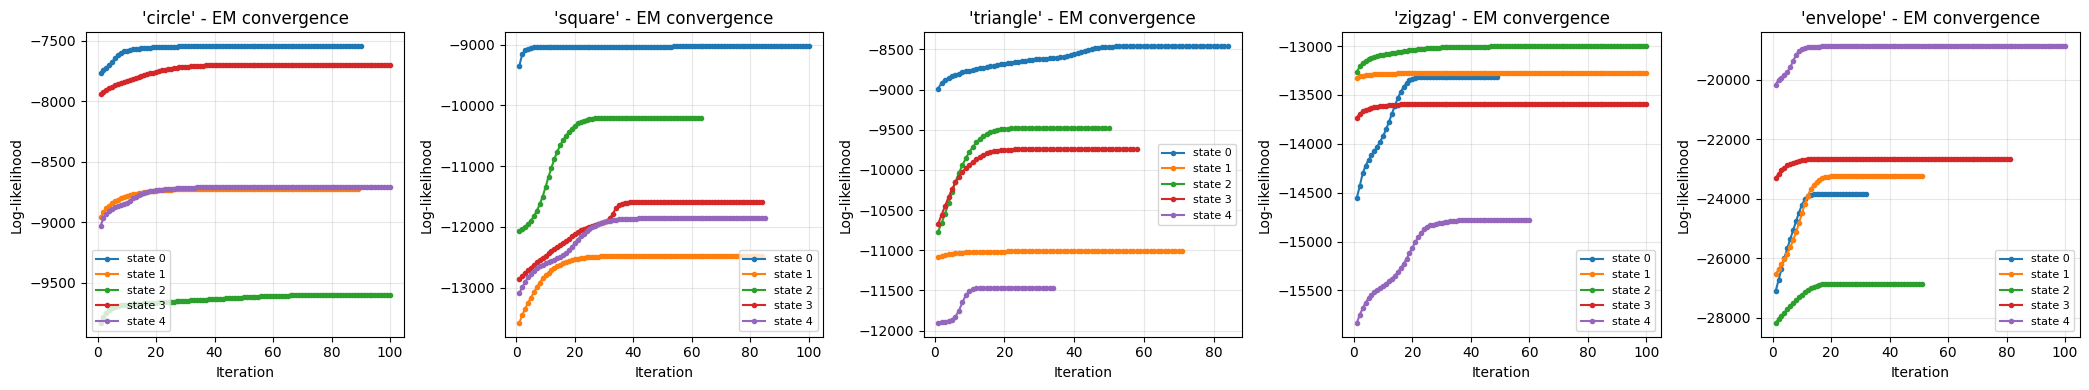

[LƯU] d:\GMMHMMquickdraw\data\training_output\01_em_convergence.png


In [21]:
plot_em_convergence(models, OUTPUT_DIR)

**Nhận xét:** tổng số vòng lặp EM (in ra ở mục 2.19) cho thấy thứ tự hội tụ nhanh → chậm là `triangle` (297) < `envelope` (315) < `zigzag` (409) ≈ `square` (416) < `circle` (479), và thứ tự này khớp với độ dài các đường cong trong plot: `triangle` là lớp duy nhất mà cả 5 trạng thái đều "bằng phẳng" trước vòng lặp 85, trong khi `circle` có state 2 (xanh lá) vẫn hội tụ chậm rãi tới tận vòng 100.

Nhìn theo từng lớp:
- **circle**: state 0 và state 3 gần như phẳng ngay từ đầu (K-means đã khởi tạo trúng vùng ổn định), nhưng state 2 tụt hẳn xuống log-likelihood thấp nhất (~-9600) và cần đủ 100 vòng lặp mới ổn định — đây là trạng thái "khó" nhất của lớp này.
- **square**: state 0 phẳng tuyệt đối ngay từ vòng đầu, nhưng 3 trạng thái còn lại (1, 3, 4) xuất phát rất thấp (~-13000) và phải mất 80-100 vòng mới hội tụ — cho thấy dữ liệu ở các đoạn giữa/cuối nét vẽ hình vuông phân tán mạnh hơn đoạn đầu.
- **triangle**: hội tụ nhanh nhất trong 5 lớp — state 1 (cam) gần như phẳng tuyệt đối suốt cả quá trình (khởi tạo đã tối ưu), state 4 (tím) tuy xuất phát rất thấp nhưng chỉ cần ~10 vòng để ổn định, phù hợp với tổng chỉ 297 vòng lặp.
- **zigzag**: state 4 (tím) có bước nhảy log-likelihood lớn nhất trong toàn bộ 5 lớp, từ khoảng -16700 vọt lên -14800 chỉ trong ~20 vòng — cho thấy khởi tạo K-means ở trạng thái này ban đầu khá tệ nhưng EM sửa được rất nhanh.
- **envelope**: log-likelihood xuất phát thấp nhất trong 5 lớp (tới -28000 ở state 2), phản ánh đây là hình phức tạp nhất (hình chữ nhật + nét nắp phong bì bên trong) nên các điểm ở mỗi trạng thái phân tán hơn hẳn các lớp hình đơn giản như triangle/square.

## 2.22. Plot 2 — Gaussian đã học theo từng trạng thái 

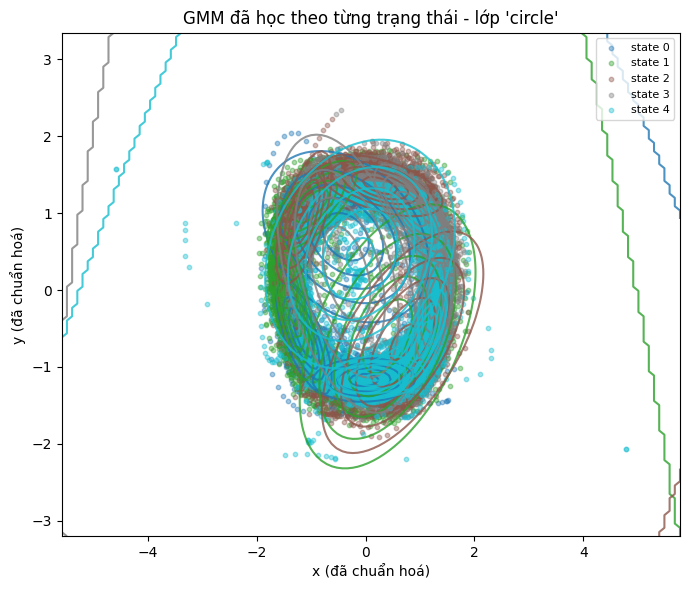

[LƯU] d:\GMMHMMquickdraw\data\training_output\02_state_gaussians_circle.png


In [22]:
plot_state_gaussians(models[CATEGORIES[0]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên

**Nhận xét:** phần lõi của hình (đa số điểm) của cả 5 trạng thái vẫn **chồng lấn gần như hoàn toàn** quanh gốc toạ độ thay vì tách thành 5 vùng riêng biệt như kỳ vọng ở mục 1.4. Nguyên nhân giống phân tích trước: `segment_sequence` chia trạng thái theo **chỉ số điểm** trong chuỗi, ngầm giả định mọi mẫu circle đều bắt đầu vẽ từ cùng 1 vị trí và cùng chiều — trong khi người vẽ QuickDraw có thể bắt đầu ở bất kỳ đâu trên vòng tròn, theo chiều kim đồng hồ hoặc ngược lại. Vì vậy "trạng thái 0" của mẫu này có thể là góc trên-trái, còn ở mẫu khác lại là góc dưới-phải, khiến GMM mỗi trạng thái phải học chung 1 hỗn hợp dữ liệu đến từ nhiều vị trí hình học khác nhau — đây là lý do `circle` (81%) và `square` (79%) là 2 lớp có accuracy thấp nhất trong 5 lớp ở mục 2.24, dù đã tăng N_STATES lên 5 và N_MIX lên 3 so với cấu hình mặc định ban đầu.

Điểm đáng chú ý thứ hai: một số ít mẫu (outlier) tạo thành các vệt điểm dạng **bậc thang** kéo dài ra tận 4 góc của biểu đồ (ví dụ vệt xanh dương ở góc trên-phải, vệt xanh lá ở góc trên-trái). Đây nhiều khả năng là những bản vẽ có nét phụ (nét thứ 2, thứ 3...) lạc xa vòng tròn chính — sau khi chuẩn hoá Z-score theo từng mẫu (`normalize_sequence`), một vài điểm lạc xa này bị kéo giãn thành giá trị cực trị, còn dạng bậc thang là do toạ độ gốc trong file `.ndjson` là số nguyên (lưới pixel) nên nhiều điểm liên tiếp trùng giá trị x hoặc y. Các mẫu này không ảnh hưởng nhiều đến vị trí contour Gaussian (vì tỉ lệ rất nhỏ so với tổng ~78.000 điểm mỗi trạng thái) nhưng cho thấy dữ liệu QuickDraw thô có nhiễu, và việc chuẩn hoá Z-score khá nhạy với outlier — có thể cân nhắc lọc hoặc dùng chuẩn hoá theo bounding box thay vì Z-score nếu muốn giảm ảnh hưởng này.

## 2.23. Plot 3 — Confusion matrix 

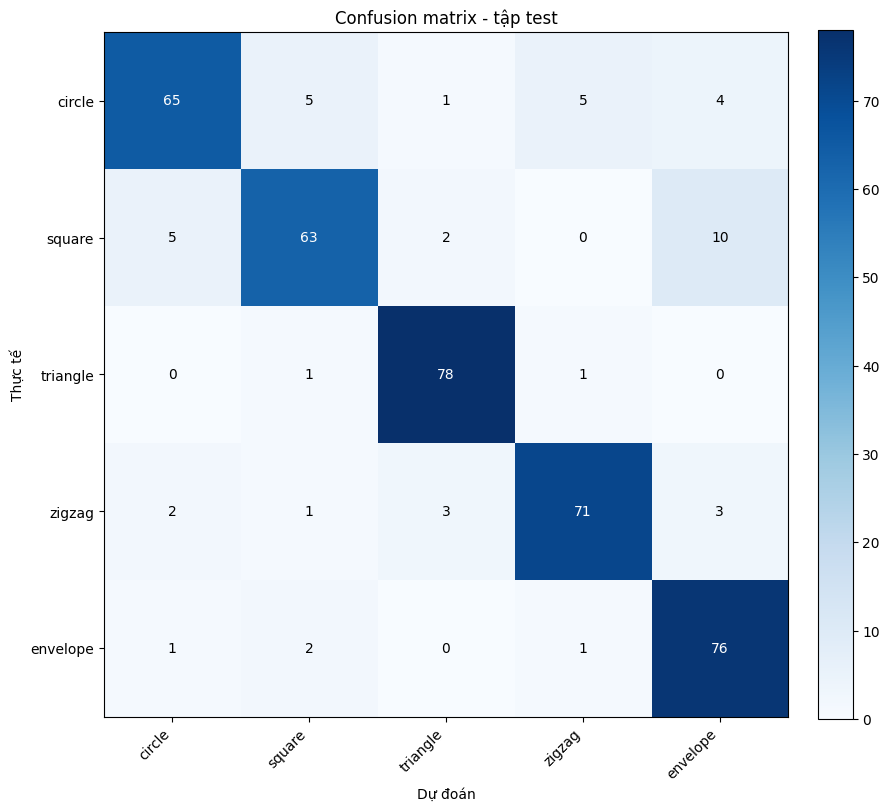

[LƯU] d:\GMMHMMquickdraw\data\training_output\03_confusion_matrix.png


In [23]:
cm = plot_confusion_matrix(y_true, y_pred, CATEGORIES, OUTPUT_DIR)

**Nhận xét:** `triangle` (78/80) là lớp được phân loại tốt nhất, gần như tuyệt đối, tiếp theo là `envelope` (76/80). Đáng chú ý nhất trong ma trận là cặp `square` → `envelope`: có tới 10/80 mẫu square (12,5%) bị đoán nhầm thành envelope — đây là ô sai lớn nhất toàn bộ ma trận, trong khi chiều ngược lại envelope chỉ bị nhầm sang square 2 lần. Sự bất đối xứng này hợp lý về mặt hình học (envelope về cơ bản chứa 1 hình chữ nhật giống square, cộng thêm vài nét nắp phong bì), nhưng cũng có thể là dấu hiệu mô hình `envelope` (do hình phức tạp hơn, xem log-likelihood thấp ở mục 2.21) học được các GMM có phương sai rộng hơn, khiến nó "dễ chấp nhận" cả những chuỗi vốn thuộc lớp `square`.

`circle` là lớp bị nhầm nhiều thứ hai (15/80 sai), nhưng khác với square, sai số của circle **trải đều** sang cả 4 lớp còn lại (5 sang square, 1 sang triangle, 5 sang zigzag, 4 sang envelope) thay vì tập trung vào 1 cặp cụ thể — khớp với hiện tượng các trạng thái của circle bị chồng lấn lan toả ở mục 2.22 (Plot 2), khiến model "phân vân" giữa nhiều lớp hơn là thiên hẳn về 1 lớp sai cụ thể. `zigzag` cũng có sai số khá dàn trải (2 circle, 1 square, 3 triangle, 3 envelope) nhưng ở mức nhẹ hơn.

## 2.24. Plot 4 — Accuracy theo từng lớp 

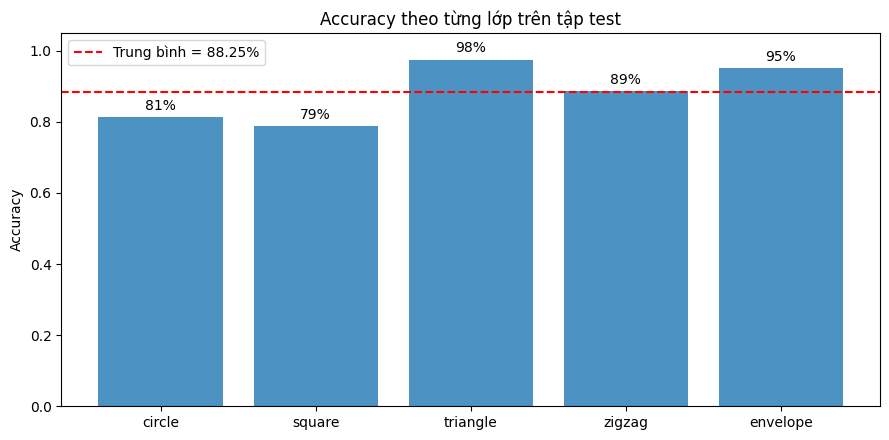

[LƯU] d:\GMMHMMquickdraw\data\training_output\04_accuracy_per_class.png


In [24]:
overall = plot_accuracy_bar(y_true, y_pred, CATEGORIES, OUTPUT_DIR)

**Nhận xét:** `square` (79%) và `circle` (81%) là 2 lớp kéo accuracy trung bình (88,25%) xuống thấp nhất, trong khi `triangle` (98%) và `envelope` (95%) dẫn đầu, `zigzag` (89%) ở mức khá — chỉ nhỉnh hơn trung bình một chút. Kết quả này khớp với 2 phân tích ở trên: `square` yếu chủ yếu do bị nhầm sang `envelope` (Plot 3), còn `circle` yếu do vấn đề chia trạng thái theo chỉ số không phù hợp với hình có tính đối xứng xoay — hình tròn không có "điểm bắt đầu" cố định về mặt hình học nên các trạng thái GMM bị chồng lấn (Plot 2). Ngược lại, `triangle` và `envelope` có các góc/cạnh và trình tự nét vẽ khá đặc trưng, nên việc chia trạng thái theo thứ tự thời gian vẽ (`segment_sequence`) phản ánh khá sát các giai đoạn hình học thực tế của 2 hình này, giúp GMM từng trạng thái học được phân phối gọn và tách biệt hơn.
